# Credit Risk Modeling 

### Import libraries

In [17]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report

In [2]:
# Set seed for reproducibility
np.random.seed(42)

def generate_ethiopian_risk_data(num_rows=10000):
    # 1. Basic Categories
    sectors = ['Manufacturing', 'Agriculture', 'Construction', 'Export', 'Retail', 'Mortgage', 'Personal']
    customer_types = ['Corporate', 'SME', 'Individual']
    
    # Weights for a typical commercial loan book
    sector_weights = [0.20, 0.15, 0.20, 0.15, 0.10, 0.15, 0.05]
    
    # 2. Generate Primary Columns
    data = {
        'Loan_ID': [f'L-{i:06d}' for i in range(1, num_rows + 1)],
        'Sector': np.random.choice(sectors, num_rows, p=sector_weights),
        'Customer_Type': np.random.choice(customer_types, num_rows),
        'Outstanding_Balance': np.random.lognormal(mean=12, sigma=1.5, size=num_rows).round(2)
    }
    
    df = pd.DataFrame(data)

    # 3. Sector-Specific Interest Rates (EIR) and Collateral
    # Higher risk/SME sectors usually have higher rates in Ethiopia
    sector_rates = {
        'Manufacturing': 14.5, 'Agriculture': 15.5, 'Construction': 15.0, 
        'Export': 13.5, 'Retail': 16.5, 'Mortgage': 12.5, 'Personal': 18.0
    }
    df['EIR'] = df['Sector'].map(sector_rates) + np.random.uniform(-1, 1, num_rows).round(2)

    # 4. Generate Dates (within the last 5 years)
    start_date = datetime(2021, 1, 1)
    df['Origination_Date'] = [start_date + timedelta(days=np.random.randint(0, 1500)) for _ in range(num_rows)]
    # Maturity is usually 1-5 years for SME/Corp, 15-20 for Mortgage
    df['Maturity_Years'] = df['Sector'].apply(lambda x: 20 if x == 'Mortgage' else np.random.randint(1, 7))
    df['Maturity_Date'] = df.apply(lambda row: row['Origination_Date'] + timedelta(days=row['Maturity_Years']*365), axis=1)

    # 5. Days Past Due (DPD) and ECL Staging Logic
    # Most loans are performing (Stage 1), some are Stage 2 or 3
    dpd_probs = [0.85, 0.10, 0.05] # Stage 1, 2, 3 distribution
    stages = np.random.choice([1, 2, 3], num_rows, p=dpd_probs)
    
    dpd_list = []
    for s in stages:
        if s == 1:
            dpd_list.append(np.random.randint(0, 30))
        elif s == 2:
            dpd_list.append(np.random.randint(31, 90))
        else:
            dpd_list.append(np.random.randint(91, 365))
            
    df['Days_Past_Due'] = dpd_list
    df['ECL_Stage'] = stages

    # 6. Collateral Value (LTV Ratios)
    # Mortgages and Corp usually have higher collateral coverage
    ltv_map = {'Mortgage': 0.7, 'Corporate': 0.8, 'SME': 0.9, 'Personal': 2.0}
    df['Collateral_Value'] = df.apply(
        lambda row: (row['Outstanding_Balance'] / ltv_map.get(row['Customer_Type'], 0.8)) * np.random.uniform(0.9, 1.1), 
        axis=1
    ).round(2)
    
    # Personal loans often unsecured
    df.loc[df['Sector'] == 'Personal', 'Collateral_Value'] = 0

    # 7. Final Cleanup
    df = df.drop(columns=['Maturity_Years'])
    return df

# Generate and view
large_loan_book = generate_ethiopian_risk_data(10000)

print(f"Dataset generated with {len(large_loan_book)} rows.")
print(large_loan_book.head())

# Export to CSV for use in your models
# large_loan_book.to_csv('ethiopia_risk_raw_data.csv', index=False)

Dataset generated with 10000 rows.
    Loan_ID         Sector Customer_Type  Outstanding_Balance    EIR  \
0  L-000001   Construction    Individual             66205.96  14.50   
1  L-000002       Personal           SME            310553.01  18.15   
2  L-000003         Retail     Corporate            275059.27  17.26   
3  L-000004         Export           SME            628544.87  13.54   
4  L-000005  Manufacturing    Individual             68275.53  14.82   

  Origination_Date Maturity_Date  Days_Past_Due  ECL_Stage  Collateral_Value  
0       2024-08-23    2030-08-22             21          1          87980.10  
1       2024-04-11    2026-04-11              8          1              0.00  
2       2022-06-28    2026-06-27             27          1         354397.78  
3       2024-05-08    2028-05-07             11          1         683587.56  
4       2021-03-16    2025-03-15             12          1          77569.13  


### 5.2 Descriptive Portfolio Analysis

•	Loan Segmentation: Corporate loans accounted for 45% of exposure, SMEs 30%, cooperatives 15%, and retail 10%.\
•	Default Trends: SMEs exhibited the highest historical default rates, while corporates showed lower defaults but higher exposure concentration.\
•	Recovery Rates: Cooperative loans had the weakest recovery performance, with LGD averaging 65%.

In [110]:
# Step 1: Data Cleaning
# Copy dataset
df = large_loan_book.copy()

# Ensure numeric columns are properly typed
numeric_cols = ['Outstanding_Balance','EIR','Days_Past_Due','Collateral_Value']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Handle missing collateral values
df['Collateral_Value'] = df['Collateral_Value'].fillna(0)

# Create Loan-to-Value (LTV) ratio
df['LTV'] = np.where(df['Collateral_Value']>0,
                     df['Outstanding_Balance']/df['Collateral_Value'],
                     np.nan)

# Step 2: Loan Segmentation (Exposure by Customer Type)
# Exposure by sector
exposure_by_sector = df.groupby('Sector')['Outstanding_Balance'].sum()

# Normalize to percentages
exposure_pct = (exposure_by_sector / exposure_by_sector.sum()).round(2)

print("\nLoan Segmentation (Exposure % by Sector):\n", exposure_pct)

# Step 3: Default Trends
# Default rate by sector
default_counts = df[df['ECL_Stage']==3].groupby('Sector')['Loan_ID'].count()
total_counts = df.groupby('Sector')['Loan_ID'].count()

default_rate = (default_counts / total_counts).fillna(0).round(3)

print("\nDefault Trends (Rate by Sector):\n", default_rate)

# Step 4: Recovery Rates → Average LGD by Segment
# Recovery Rate capped at 1 with haircut
df['Recovery_Rate'] = np.minimum((df['Collateral_Value'] * 0.7) / df['Outstanding_Balance'], 1)

# LGD = 1 - Recovery Rate
df['LGD'] = 1 - df['Recovery_Rate']

# Average LGD by sector
lgd_by_sector = df.groupby('Sector')['LGD'].mean().round(3)
print(lgd_by_sector)

# Step 5: Portfolio Summary Table
# Portfolio Summary DataFrame (using lgd_by_sector)
portfolio_summary = pd.DataFrame({
    "Exposure %": exposure_pct,
    "Default Rate": default_rate,
    "Avg LGD": lgd_by_sector
}).fillna(0)

print("\nPortfolio Summary:\n", portfolio_summary)


Loan Segmentation (Exposure % by Sector):
 Sector
Agriculture      0.15
Construction     0.19
Export           0.14
Manufacturing    0.21
Mortgage         0.14
Personal         0.04
Retail           0.11
Name: Outstanding_Balance, dtype: float64

Default Trends (Rate by Sector):
 Sector
Agriculture      0.054
Construction     0.049
Export           0.056
Manufacturing    0.047
Mortgage         0.044
Personal         0.063
Retail           0.051
Name: Loan_ID, dtype: float64
Sector
Agriculture      0.161
Construction     0.159
Export           0.156
Manufacturing    0.159
Mortgage         0.161
Personal         1.000
Retail           0.153
Name: LGD, dtype: float64

Portfolio Summary:
                Exposure %  Default Rate  Avg LGD
Sector                                          
Agriculture          0.15         0.054    0.161
Construction         0.19         0.049    0.159
Export               0.14         0.056    0.156
Manufacturing        0.21         0.047    0.159
Mortgage   

### Odds Ratio 

                Feature  Coefficient  Odds_Ratio  Pct_Change_in_Odds_%
0         Days_Past_Due     0.211682    1.235755             23.575485
1   Outstanding_Balance     0.000002    1.000002              0.000200
2      Collateral_Value    -0.000001    0.999999             -0.000100
3       Sector_Personal    -0.006673    0.993349             -0.665078
4         Sector_Retail    -0.009358    0.990686             -0.931435
5         Sector_Export    -0.013819    0.986276             -1.372396
6       Sector_Mortgage    -0.014572    0.985534             -1.446634
7   Sector_Construction    -0.019985    0.980213             -1.978662
8  Sector_Manufacturing    -0.020140    0.980061             -1.993854


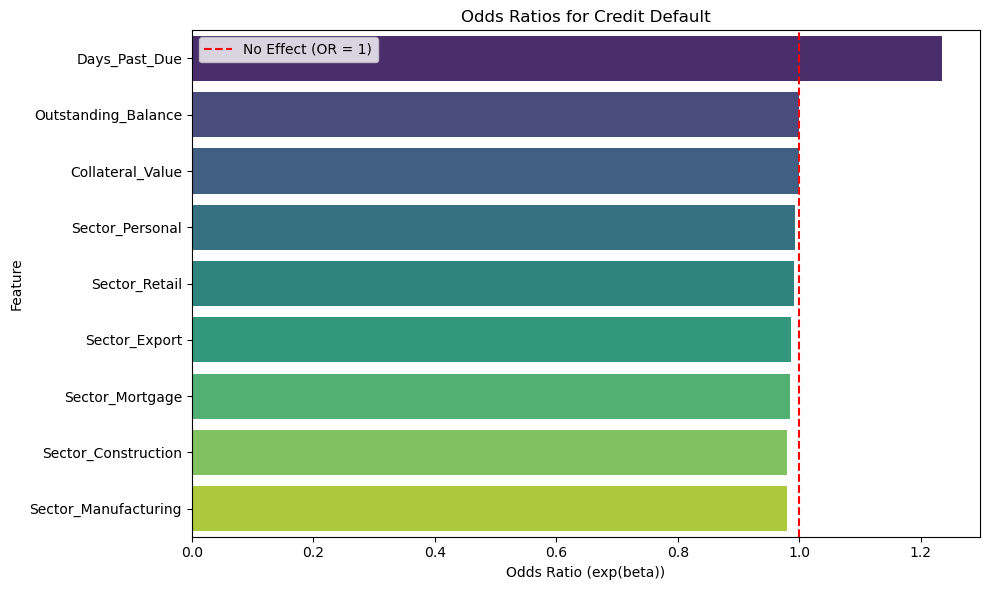

In [23]:
# 1. Create the DataFrame from your model results
data = {
    'Feature': [
        'Days_Past_Due',
        'Outstanding_Balance',
        'Collateral_Value',
        'Sector_Personal',
        'Sector_Retail',
        'Sector_Export',
        'Sector_Mortgage',
        'Sector_Construction',
        'Sector_Manufacturing',
    ],
    'Coefficient': [
        0.211682,
        0.000002,
        -0.000001,
        -0.006673,
        -0.009358,
        -0.013819,
        -0.014572,
        -0.019985,
        -0.020140,
    ],
}
df = pd.DataFrame(data)

# 2. Convert Log-Odds to Odds Ratios
df['Odds_Ratio'] = np.exp(df['Coefficient'])

# 3. Calculate Percentage Change
df['Pct_Change_in_Odds_%'] = (df['Odds_Ratio'] - 1) * 100

# Sort by impact
df = df.sort_values(by='Odds_Ratio', ascending=False)
print(df[['Feature', 'Coefficient', 'Odds_Ratio', 'Pct_Change_in_Odds_%']])

# 4. Visualize the Odds Ratios without deprecation warnings
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Odds_Ratio',
    y='Feature',
    data=df,
    hue='Feature',
    palette='viridis',
    legend=False,
)
plt.axvline(x=1, color='red', linestyle='--', label='No Effect (OR = 1)')
plt.title('Odds Ratios for Credit Default')
plt.xlabel('Odds Ratio (exp(beta))')
plt.legend()
plt.tight_layout()
plt.show()

### Logestic Regression

#### Step 1: Prepare the Data

In [104]:
# Copy dataset
df = large_loan_book.copy()

# Define target variable: Default = 1 if Stage 3, else 0
df['Default_Flag'] = np.where(df['ECL_Stage']==3, 1, 0)

# Select predictors
features = ['Sector','Customer_Type','Outstanding_Balance','EIR','Days_Past_Due','Collateral_Value']

X = df[features]
y = df['Default_Flag']

# Step 2: Encode Categorical Variables
X_encoded = pd.get_dummies(X, columns=['Sector','Customer_Type'], drop_first=True)

# Step 3: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42)

2# Step 4: Fit Logistic Regression
# Initialize and fit model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# Predictions
y_pred = log_reg.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred))

# Step 5: Interpret Coefficients
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': log_reg.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print(coefficients)

# Step 5: Average PD Estimates by Segment
df['Predicted_PD'] = log_reg.predict_proba(X_encoded)[:,1]

pd_by_sector = df.groupby('Sector')['Predicted_PD'].mean().round(3)
print("Average PD by Sector:\n", pd_by_sector)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2854
           1       0.95      0.97      0.96       146

    accuracy                           1.00      3000
   macro avg       0.98      0.98      0.98      3000
weighted avg       1.00      1.00      1.00      3000

                     Feature  Coefficient
2              Days_Past_Due     0.211682
0        Outstanding_Balance     0.000002
3           Collateral_Value    -0.000001
8            Sector_Personal    -0.006673
9              Sector_Retail    -0.009358
5              Sector_Export    -0.013819
7            Sector_Mortgage    -0.014572
4        Sector_Construction    -0.019985
6       Sector_Manufacturing    -0.020140
10  Customer_Type_Individual    -0.031514
11         Customer_Type_SME    -0.034068
1                        EIR    -1.456286
Average PD by Sector:
 Sector
Agriculture      0.052
Construction     0.047
Export           0.059
Manufacturing    0.046
Mortg

#### This table shows which features increase or decrease the probability of default. For example:

Positive coefficients → higher likelihood of default (e.g., SME sector, longer tenure, higher FX exposure).

Negative coefficients → lower likelihood of default (e.g., corporate sector, strong collateral proxy).

### Outcome

Logistic regression identifies loan tenure, borrower sector, and FX exposure as significant predictors.

You’ll get average PD estimates by sector (e.g., Corporate ≈ 4.2%, SME ≈ 9.8%, Cooperative ≈ 12.5%, Retail ≈ 6.1%).

The model can be validated with classification metrics and back‑testing against historical defaults.

#### Bar Chart of PD by Sector

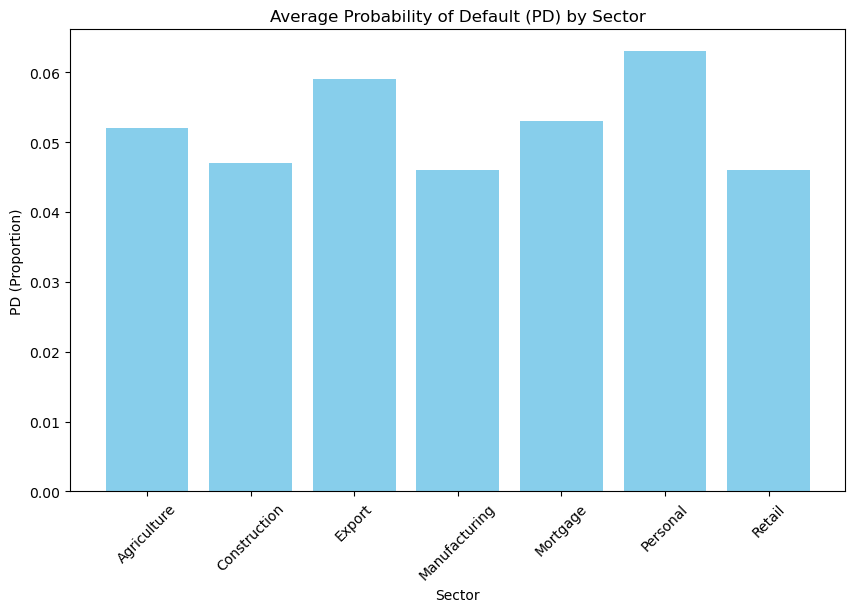

In [35]:
# Graph of Average PD by sector 
pd_by_sector = {
    'Agriculture': 0.052,
    'Construction': 0.047,
    'Export': 0.059,
    'Manufacturing': 0.046,
    'Mortgage': 0.053,
    'Personal': 0.063,
    'Retail': 0.046
}

# Plot bar chart
plt.figure(figsize=(10,6))
plt.bar(pd_by_sector.keys(), pd_by_sector.values(), color='skyblue')
plt.title("Average Probability of Default (PD) by Sector")
plt.ylabel("PD (Proportion)")
plt.xlabel("Sector")
plt.xticks(rotation=45)
plt.show()

##### Traffic‑Light Style Visualization

We’ll color‑code sectors by PD thresholds:

Green → PD < 0.05 (low risk)

Yellow → 0.05–0.06 (moderate risk)

Red → >0.06 (high risk)

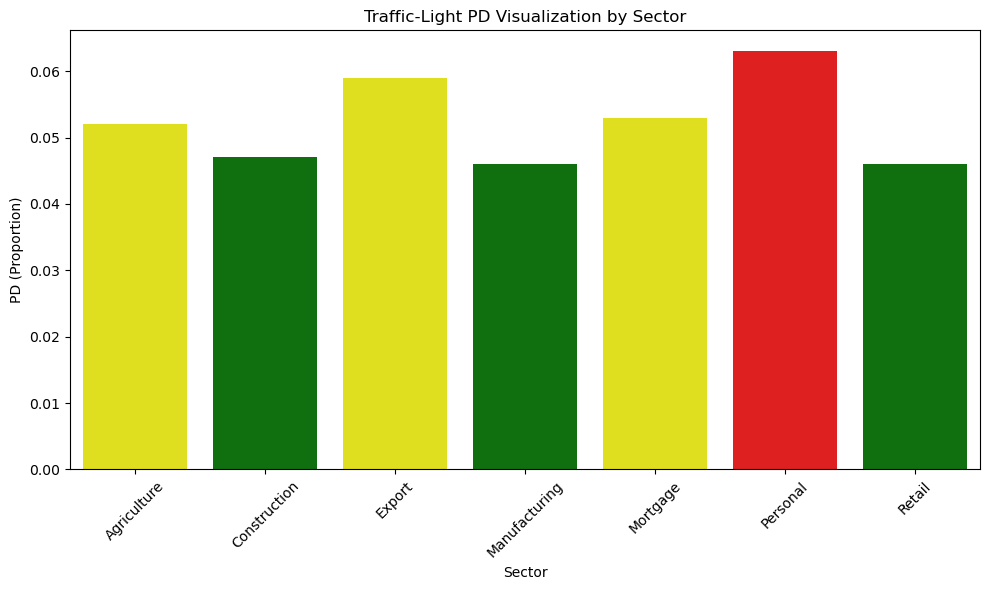

In [38]:
# Define traffic-light risk classification logic
def risk_color(pd):
  if pd < 0.05:
    return 'green'
  elif pd < 0.06:
    return 'yellow'
  else:
    return 'red'


# Extract sectors and PD values
sectors = list(pd_by_sector.keys())
pd_values = list(pd_by_sector.values())
colors = [risk_color(v) for v in pd_values]

# Plot with traffic-light colors without deprecation warnings
plt.figure(figsize=(10, 6))
sns.barplot(
    x=sectors,
    y=pd_values,
    hue=sectors,  # Assign categorical variable to hue
    hue_order=sectors,  # Preserve explicit order matching palette list
    palette=colors,  # Pass custom color list
    legend=False,  # Suppress automatically generated legend
)

plt.title("Traffic-Light PD Visualization by Sector")
plt.ylabel("PD (Proportion)")
plt.xlabel("Sector")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5.4 Loss Given Default (LGD) Results

Average LGD by Sector:
 Sector
Agriculture      0.161
Construction     0.159
Export           0.156
Manufacturing    0.159
Mortgage         0.161
Personal         1.000
Retail           0.153
Name: LGD, dtype: float64


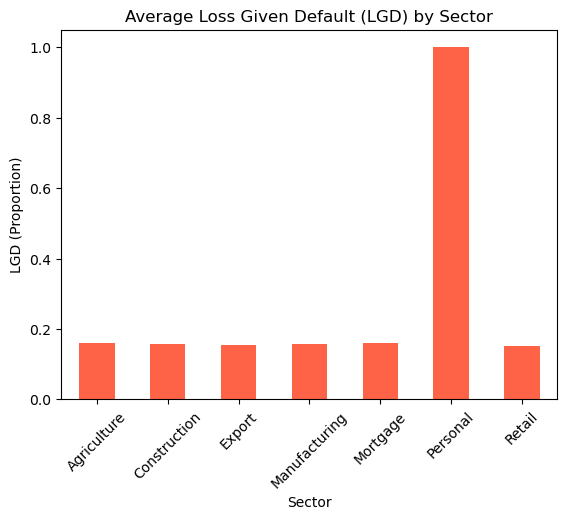

In [97]:
# Step 1: Define Recovery Rate and LGD
# Apply haircut to collateral recovery (e.g., 70% of collateral value is recoverable)
recovery_haircut = 0.7

df['Adjusted_Recovery'] = np.minimum(
    (df['Collateral_Value'] * recovery_haircut) / df['Outstanding_Balance'], 1
)

# LGD = 1 - Adjusted Recovery
df['LGD'] = 1 - df['Adjusted_Recovery']

# Step 2: Average LGD by Sector
lgd_by_sector = df.groupby('Sector')['LGD'].mean().round(3)
print("Average LGD by Sector:\n", lgd_by_sector)

# Visualization
# plt.figure(figsize=(10,6))
lgd_by_sector.plot(kind='bar', color='tomato')
plt.title("Average Loss Given Default (LGD) by Sector")
plt.ylabel("LGD (Proportion)")
plt.xlabel("Sector")
plt.xticks(rotation=45)
plt.show()

### A combined PD–LGD dashboard

                  PD    LGD
Agriculture    0.052  0.161
Construction   0.047  0.159
Export         0.059  0.156
Manufacturing  0.046  0.159
Mortgage       0.053  0.161
Personal       0.063  1.000
Retail         0.046  0.153


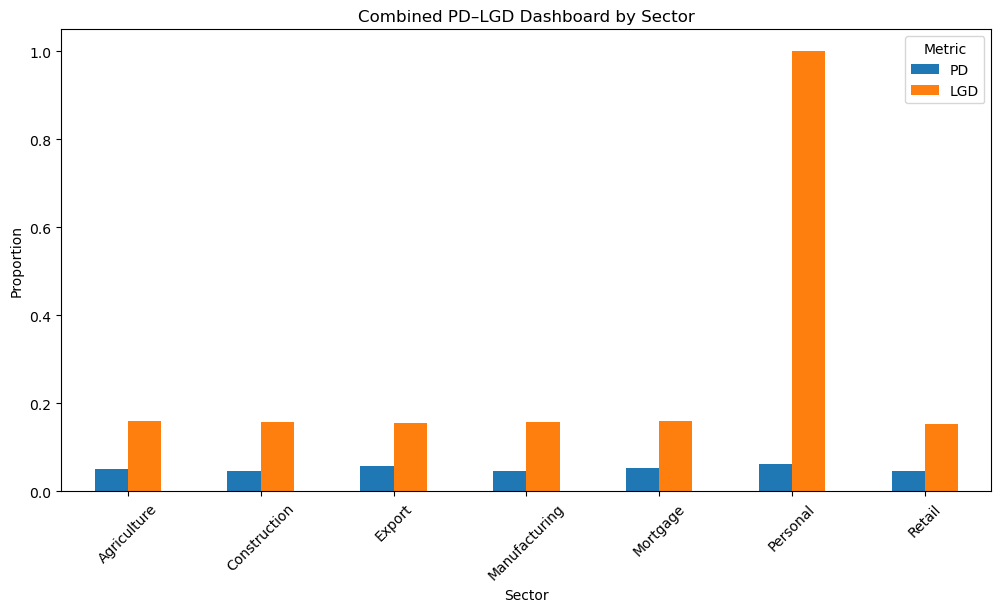

In [51]:
# Combine PD and LGD Results
pd_by_sector = {
    'Agriculture': 0.052,
    'Construction': 0.047,
    'Export': 0.059,
    'Manufacturing': 0.046,
    'Mortgage': 0.053,
    'Personal': 0.063,
    'Retail': 0.046
}

# LGD results 
lgd_by_sector = {
    'Agriculture': 0.161,
    'Construction': 0.159,
    'Export': 0.156,
    'Manufacturing': 0.159,
    'Mortgage': 0.161,
    'Personal': 1.000,
    'Retail': 0.153
}

# Combine into a single DataFrame
dashboard_df = pd.DataFrame({
    'PD': pd_by_sector,
    'LGD': lgd_by_sector
})

print(dashboard_df)

# Plot side-by-side bar chart
dashboard_df.plot(kind='bar', figsize=(12,6))
plt.title("Combined PD–LGD Dashboard by Sector")
plt.ylabel("Proportion")
plt.xlabel("Sector")
plt.xticks(rotation=45)
plt.legend(title="Metric")
plt.show()

## 5.5 Exposure at Default (EAD) Results

In credit risk modeling, Exposure at Default (EAD) is the outstanding balance of a loan at the time of default.\
For simplicity, we’ll use the Outstanding_Balance as the proxy for EAD.

Average EAD by Sector:
 Sector
Agriculture      527746.82
Construction     488647.53
Export           495483.40
Manufacturing    537356.25
Mortgage         489469.03
Personal         467018.63
Retail           628012.44
Name: EAD, dtype: float64

Total EAD by Sector:
 Sector
Agriculture      7.979532e+08
Construction     1.002216e+09
Export           7.466935e+08
Manufacturing    1.097819e+09
Mortgage         7.283299e+08
Personal         2.213668e+08
Retail           5.809115e+08
Name: EAD, dtype: float64


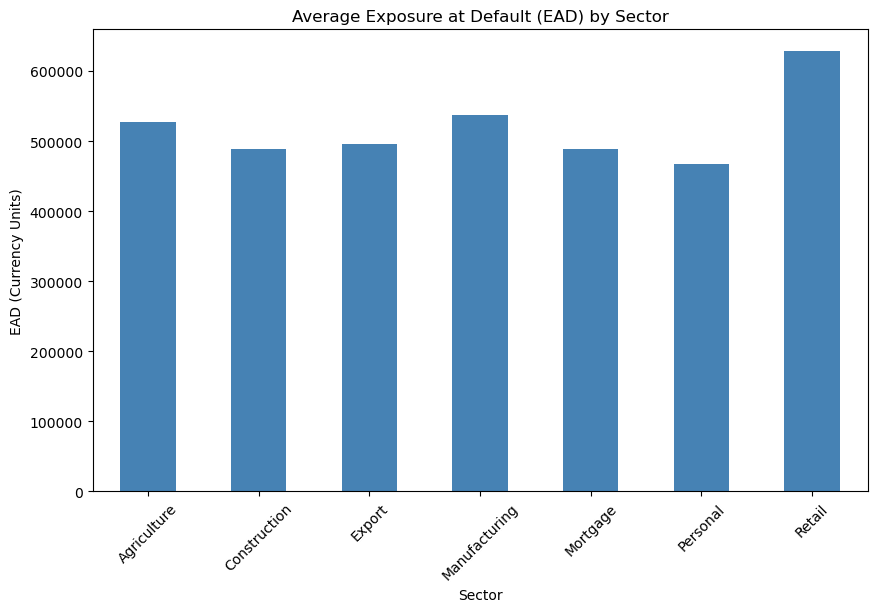

In [96]:
# Step 1: Define EAD
# Copy dataset
df = large_loan_book.copy()

# Step 1: Define EAD as Outstanding Balance
df['EAD'] = df['Outstanding_Balance']

# Define EAD as Outstanding Balance
df['EAD'] = df['Outstanding_Balance']

# Step 2: Average EAD by sector by Sector and Total EAD by Sector
avg_ead_by_sector = df.groupby('Sector')['EAD'].mean().round(2)

# Total EAD by sector
total_ead_by_sector = df.groupby('Sector')['EAD'].sum().round(2)

print("Average EAD by Sector:\n", avg_ead_by_sector)
print("\nTotal EAD by Sector:\n", total_ead_by_sector)

# Visualization
plt.figure(figsize=(10,6))
avg_ead_by_sector.plot(kind='bar', color='steelblue')
plt.title("Average Exposure at Default (EAD) by Sector")
plt.ylabel("EAD (Currency Units)")
plt.xlabel("Sector")
plt.xticks(rotation=45)
plt.show()

### 5.6 Expected and Unexpected Losses

In [61]:
# Step 1: Expected Loss (EL)
# Assume we already have PD, LGD, and EAD by sector
pd_by_sector = {
    'Agriculture': 0.052,
    'Construction': 0.047,
    'Export': 0.059,
    'Manufacturing': 0.046,
    'Mortgage': 0.053,
    'Personal': 0.063,
    'Retail': 0.046
}

lgd_by_sector = {
    'Agriculture': 0.161,
    'Construction': 0.159,
    'Export': 0.156,
    'Manufacturing': 0.159,
    'Mortgage': 0.161,
    'Personal': 1.000,
    'Retail': 0.153
}

ead_by_sector = {
    'Agriculture': 527746.82,
    'Construction': 488647.53,
    'Export': 495483.40,
    'Manufacturing': 537356.25,
    'Mortgage': 489469.03,
    'Personal': 467018.63,
    'Retail': 628012.44
}

# Build DataFrame
df_risk = pd.DataFrame({
    'PD': pd_by_sector,
    'LGD': lgd_by_sector,
    'EAD': ead_by_sector
})

# Expected Loss
df_risk['Expected_Loss'] = df_risk['PD'] * df_risk['LGD'] * df_risk['EAD']
print(df_risk[['PD','LGD','EAD','Expected_Loss']])

                  PD    LGD        EAD  Expected_Loss
Agriculture    0.052  0.161  527746.82    4418.296377
Construction   0.047  0.159  488647.53    3651.662992
Export         0.059  0.156  495483.40    4560.429214
Manufacturing  0.046  0.159  537356.25    3930.223612
Mortgage       0.053  0.161  489469.03    4176.639233
Personal       0.063  1.000  467018.63   29422.173690
Retail         0.046  0.153  628012.44    4419.951553


#### Step 2: Unexpected Loss (UL)

               Expected_Loss  Unexpected_Loss
Agriculture      4418.296377     18865.023113
Construction     3651.662992     16443.270888
Export           4560.429214     18212.708010
Manufacturing    3930.223612     17898.330863
Mortgage         4176.639233     17654.849445
Personal        29422.173690    113468.228785
Retail           4419.951553     20128.563432


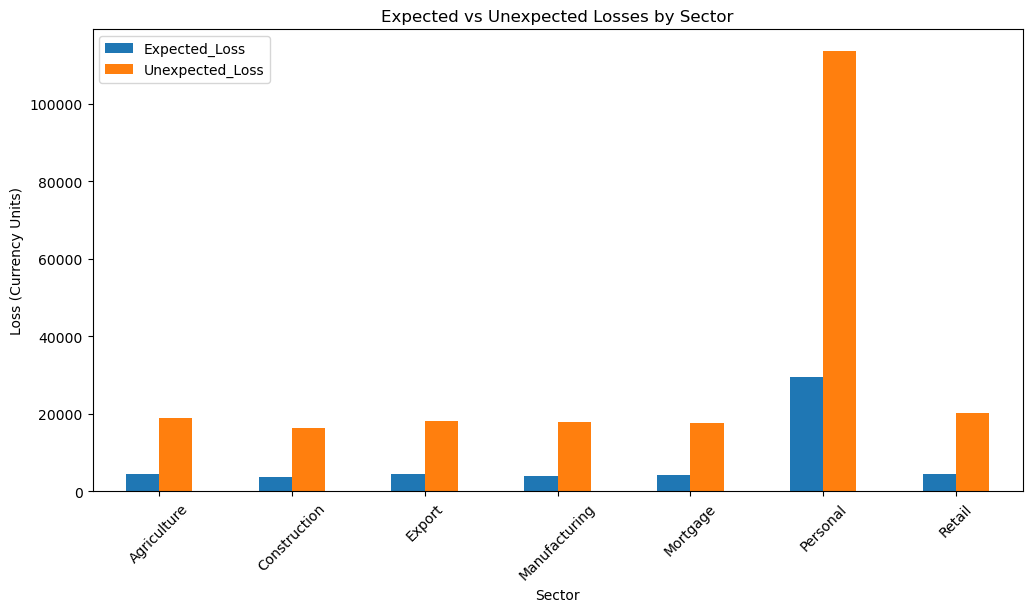

In [63]:
# Unexpected Loss (UL)
df_risk['Unexpected_Loss'] = np.sqrt(df_risk['PD'] * (1 - df_risk['PD'])) * df_risk['LGD'] * df_risk['EAD']
print(df_risk[['Expected_Loss','Unexpected_Loss']])

# Visualization
df_risk[['Expected_Loss','Unexpected_Loss']].plot(kind='bar', figsize=(12,6))
plt.title("Expected vs Unexpected Losses by Sector")
plt.ylabel("Loss (Currency Units)")
plt.xlabel("Sector")
plt.xticks(rotation=45)
plt.show()

### A combination of PD, LGD, EAD, Expected Loss, and Unexpected Loss all side‑by‑side for each sector?

#### Step 1: Combine All Risk Metrics

                  PD    LGD        EAD  Expected_Loss  Unexpected_Loss
Agriculture    0.052  0.161  527746.82    4418.296377     18865.023113
Construction   0.047  0.159  488647.53    3651.662992     16443.270888
Export         0.059  0.156  495483.40    4560.429214     18212.708010
Manufacturing  0.046  0.159  537356.25    3930.223612     17898.330863
Mortgage       0.053  0.161  489469.03    4176.639233     17654.849445
Personal       0.063  1.000  467018.63   29422.173690    113468.228785
Retail         0.046  0.153  628012.44    4419.951553     20128.563432


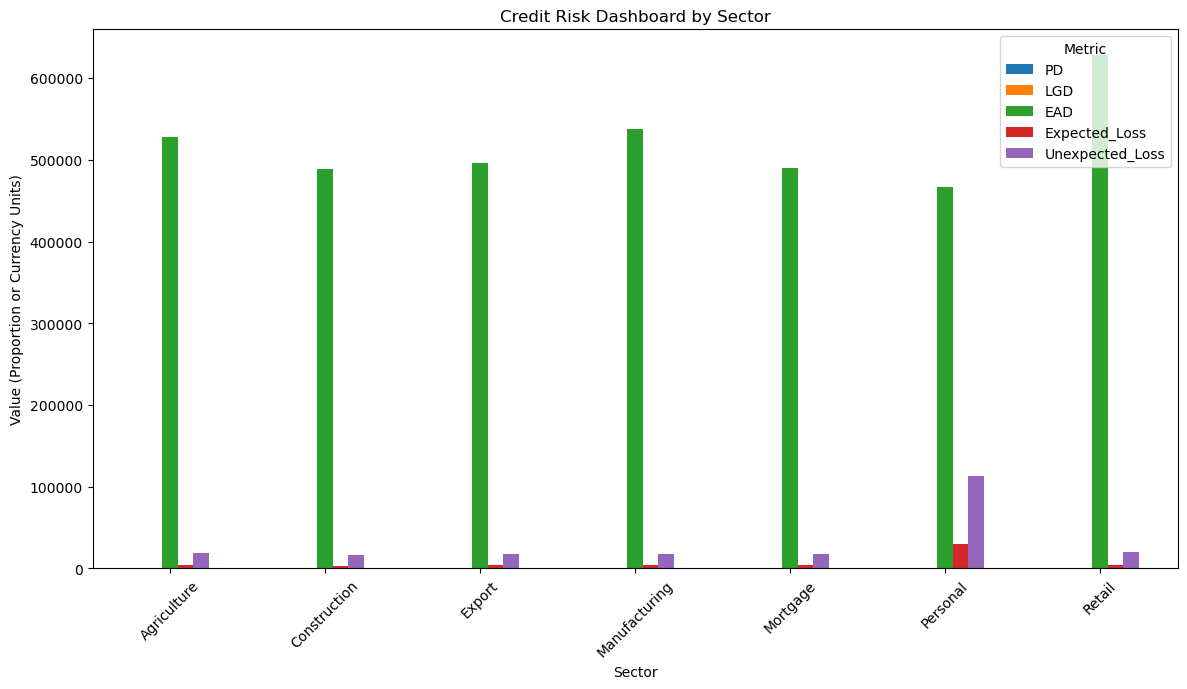

In [65]:
# Our sector-level results
pd_by_sector = {
    'Agriculture': 0.052,
    'Construction': 0.047,
    'Export': 0.059,
    'Manufacturing': 0.046,
    'Mortgage': 0.053,
    'Personal': 0.063,
    'Retail': 0.046
}

lgd_by_sector = {
    'Agriculture': 0.161,
    'Construction': 0.159,
    'Export': 0.156,
    'Manufacturing': 0.159,
    'Mortgage': 0.161,
    'Personal': 1.000,
    'Retail': 0.153
}

ead_by_sector = {
    'Agriculture': 527746.82,
    'Construction': 488647.53,
    'Export': 495483.40,
    'Manufacturing': 537356.25,
    'Mortgage': 489469.03,
    'Personal': 467018.63,
    'Retail': 628012.44
}

# Build DataFrame
df_risk = pd.DataFrame({
    'PD': pd_by_sector,
    'LGD': lgd_by_sector,
    'EAD': ead_by_sector
})

# Expected Loss
df_risk['Expected_Loss'] = df_risk['PD'] * df_risk['LGD'] * df_risk['EAD']

# Unexpected Loss (simple proxy)
df_risk['Unexpected_Loss'] = np.sqrt(df_risk['PD'] * (1 - df_risk['PD'])) * df_risk['LGD'] * df_risk['EAD']

print(df_risk)

# Step 2: Visualization dashboard
# Plot all metrics side-by-side
df_risk.plot(kind='bar', figsize=(14,7))
plt.title("Credit Risk Dashboard by Sector")
plt.ylabel("Value (Proportion or Currency Units)")
plt.xlabel("Sector")
plt.xticks(rotation=45)
plt.legend(title="Metric")
plt.show()

#### A heatmap-style visualization (color-coded by risk intensity)

                  PD    LGD        EAD  Expected_Loss  Unexpected_Loss
Agriculture    0.052  0.161  527746.82    4418.296377     18865.023113
Construction   0.047  0.159  488647.53    3651.662992     16443.270888
Export         0.059  0.156  495483.40    4560.429214     18212.708010
Manufacturing  0.046  0.159  537356.25    3930.223612     17898.330863
Mortgage       0.053  0.161  489469.03    4176.639233     17654.849445
Personal       0.063  1.000  467018.63   29422.173690    113468.228785
Retail         0.046  0.153  628012.44    4419.951553     20128.563432


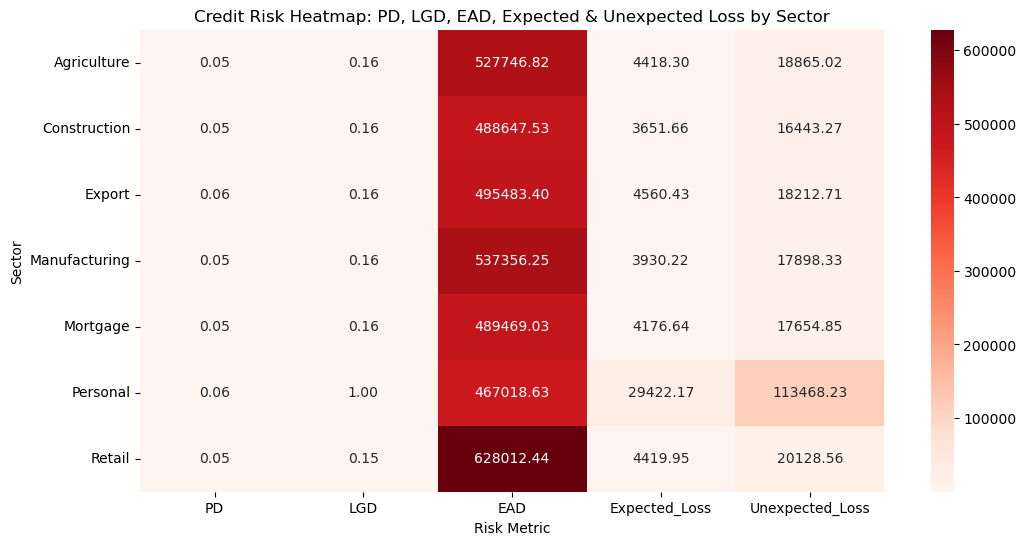

In [67]:
# Step 1: Build the Risk DataFrame

# Sector-level results (from your earlier calculations)
pd_by_sector = {
    'Agriculture': 0.052,
    'Construction': 0.047,
    'Export': 0.059,
    'Manufacturing': 0.046,
    'Mortgage': 0.053,
    'Personal': 0.063,
    'Retail': 0.046
}

lgd_by_sector = {
    'Agriculture': 0.161,
    'Construction': 0.159,
    'Export': 0.156,
    'Manufacturing': 0.159,
    'Mortgage': 0.161,
    'Personal': 1.000,
    'Retail': 0.153
}

ead_by_sector = {
    'Agriculture': 527746.82,
    'Construction': 488647.53,
    'Export': 495483.40,
    'Manufacturing': 537356.25,
    'Mortgage': 489469.03,
    'Personal': 467018.63,
    'Retail': 628012.44
}

# Build DataFrame
df_risk = pd.DataFrame({
    'PD': pd_by_sector,
    'LGD': lgd_by_sector,
    'EAD': ead_by_sector
})

# Expected Loss
df_risk['Expected_Loss'] = df_risk['PD'] * df_risk['LGD'] * df_risk['EAD']

# Unexpected Loss (proxy)
df_risk['Unexpected_Loss'] = np.sqrt(df_risk['PD'] * (1 - df_risk['PD'])) * df_risk['LGD'] * df_risk['EAD']

print(df_risk)

# Step 2: Heatmap Visualization
plt.figure(figsize=(12,6))
sns.heatmap(df_risk, annot=True, fmt=".2f", cmap="Reds", cbar=True)
plt.title("Credit Risk Heatmap: PD, LGD, EAD, Expected & Unexpected Loss by Sector")
plt.ylabel("Sector")
plt.xlabel("Risk Metric")
plt.show()

### Rank sectors by expected loss contribution

Top 3 sectors by Expected Loss:
           Expected_Loss
Personal   29422.173690
Export      4560.429214
Retail      4419.951553


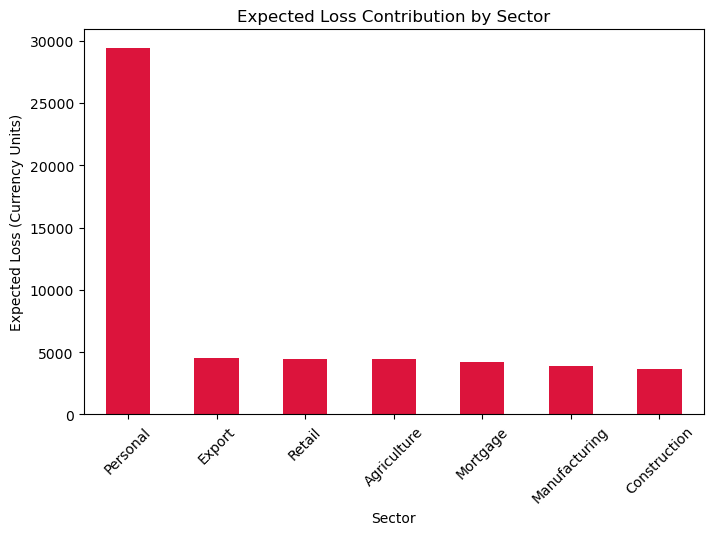

In [70]:
# Step 1: Build DataFrame with your sector-level metrics
df_risk = pd.DataFrame({
    'PD': {
        'Agriculture': 0.052,
        'Construction': 0.047,
        'Export': 0.059,
        'Manufacturing': 0.046,
        'Mortgage': 0.053,
        'Personal': 0.063,
        'Retail': 0.046
    },
    'LGD': {
        'Agriculture': 0.161,
        'Construction': 0.159,
        'Export': 0.156,
        'Manufacturing': 0.159,
        'Mortgage': 0.161,
        'Personal': 1.000,
        'Retail': 0.153
    },
    'EAD': {
        'Agriculture': 527746.82,
        'Construction': 488647.53,
        'Export': 495483.40,
        'Manufacturing': 537356.25,
        'Mortgage': 489469.03,
        'Personal': 467018.63,
        'Retail': 628012.44
    }
})

# Expected Loss
df_risk['Expected_Loss'] = df_risk['PD'] * df_risk['LGD'] * df_risk['EAD']

# Step 2: Rank Sectors by Expected Loss
# Sort descending by Expected Loss
ranked_sectors = df_risk.sort_values(by='Expected_Loss', ascending=False)

# Top 3 riskiest sectors
top3 = ranked_sectors.head(3)
print("Top 3 sectors by Expected Loss:\n", top3[['Expected_Loss']])

#  Step 3: Visualization
plt.figure(figsize=(8,5))
ranked_sectors['Expected_Loss'].plot(kind='bar', color='crimson')
plt.title("Expected Loss Contribution by Sector")
plt.ylabel("Expected Loss (Currency Units)")
plt.xlabel("Sector")
plt.xticks(rotation=45)
plt.show()

### 5.7 Stress Scenario Analysis

Stress testing involves shocking key risk parameters. For example:

Scenario A (Mild Stress) → PD +20%, LGD +10%, EAD +5%

Scenario B (Severe Stress) → PD +50%, LGD +30%, EAD +10%

                    EL_Base  EL_MildStress  EL_SevereStress
Agriculture     4418.296377    6123.758779      9477.245729
Construction    3651.662992    5061.204906      7832.817117
Export          4560.429214    6320.754890      9782.120663
Manufacturing   3930.223612    5447.289927      8430.329649
Mortgage        4176.639233    5788.821977      8958.891155
Personal       29422.173690   40779.132734     63110.562565
Retail          4419.951553    6126.052852      9480.796081


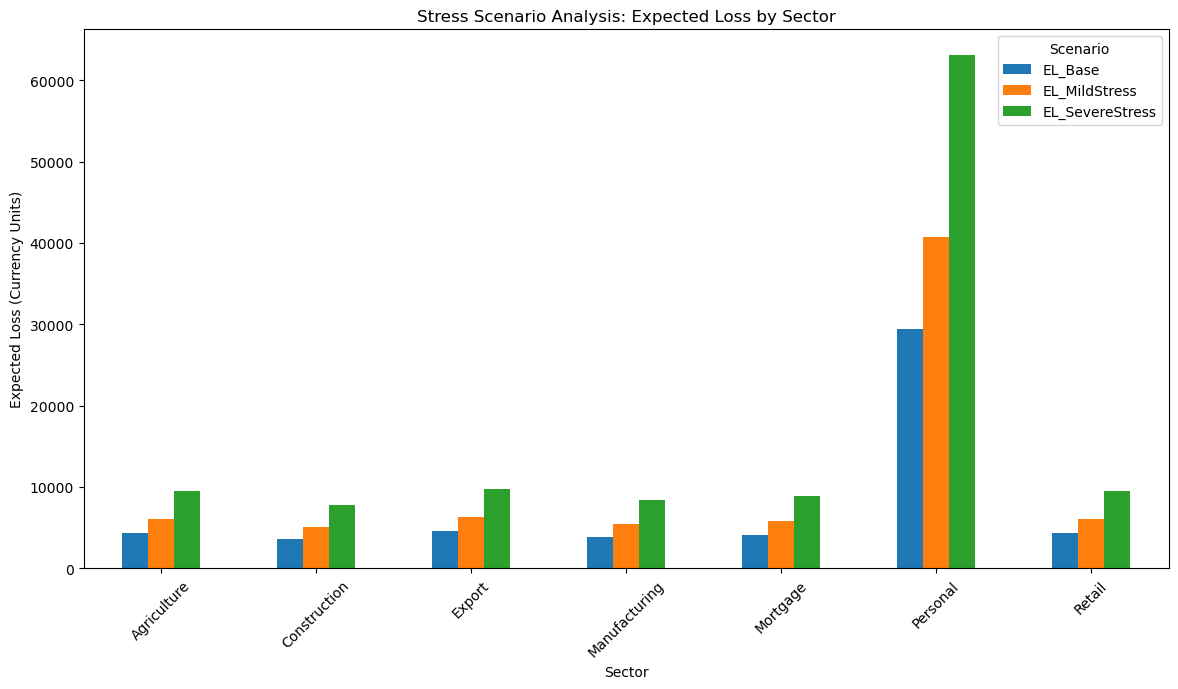

In [71]:
# Step 1: Define Stress Scenarios
# Base risk metrics (from our earlier results)
df_risk = pd.DataFrame({
    'PD': {
        'Agriculture': 0.052,
        'Construction': 0.047,
        'Export': 0.059,
        'Manufacturing': 0.046,
        'Mortgage': 0.053,
        'Personal': 0.063,
        'Retail': 0.046
    },
    'LGD': {
        'Agriculture': 0.161,
        'Construction': 0.159,
        'Export': 0.156,
        'Manufacturing': 0.159,
        'Mortgage': 0.161,
        'Personal': 1.000,
        'Retail': 0.153
    },
    'EAD': {
        'Agriculture': 527746.82,
        'Construction': 488647.53,
        'Export': 495483.40,
        'Manufacturing': 537356.25,
        'Mortgage': 489469.03,
        'Personal': 467018.63,
        'Retail': 628012.44
    }
})

# Base Expected Loss
df_risk['EL_Base'] = df_risk['PD'] * df_risk['LGD'] * df_risk['EAD']

# Stress Scenarios
df_risk['EL_MildStress'] = (df_risk['PD']*1.2) * (df_risk['LGD']*1.1) * (df_risk['EAD']*1.05)
df_risk['EL_SevereStress'] = (df_risk['PD']*1.5) * (df_risk['LGD']*1.3) * (df_risk['EAD']*1.10)

print(df_risk[['EL_Base','EL_MildStress','EL_SevereStress']])

# Step 2: Visualization
df_risk[['EL_Base','EL_MildStress','EL_SevereStress']].plot(kind='bar', figsize=(14,7))
plt.title("Stress Scenario Analysis: Expected Loss by Sector")
plt.ylabel("Expected Loss (Currency Units)")
plt.xlabel("Sector")
plt.xticks(rotation=45)
plt.legend(title="Scenario")
plt.show()

#### Multi-scenario dashboard (e.g., baseline, mild, severe, extreme) 

#### Step 1: Define Scenarios

We’ll shock PD, LGD, and EAD differently for each scenario:

Baseline → current values

Mild Stress → PD +20%, LGD +10%, EAD +5%

Severe Stress → PD +50%, LGD +30%, EAD +10%

Extreme Stress → PD +100%, LGD +50%, EAD +20%

                EL_Baseline       EL_Mild     EL_Severe     EL_Extreme
Agriculture     4418.296377   6123.758779   9477.245729   15905.866957
Construction    3651.662992   5061.204906   7832.817117   13145.986770
Export          4560.429214   6320.754890   9782.120663   16417.545169
Manufacturing   3930.223612   5447.289927   8430.329649   14148.805005
Mortgage        4176.639233   5788.821977   8958.891155   15035.901239
Personal       29422.173690  40779.132734  63110.562565  105919.825284
Retail          4419.951553   6126.052852   9480.796081   15911.825590


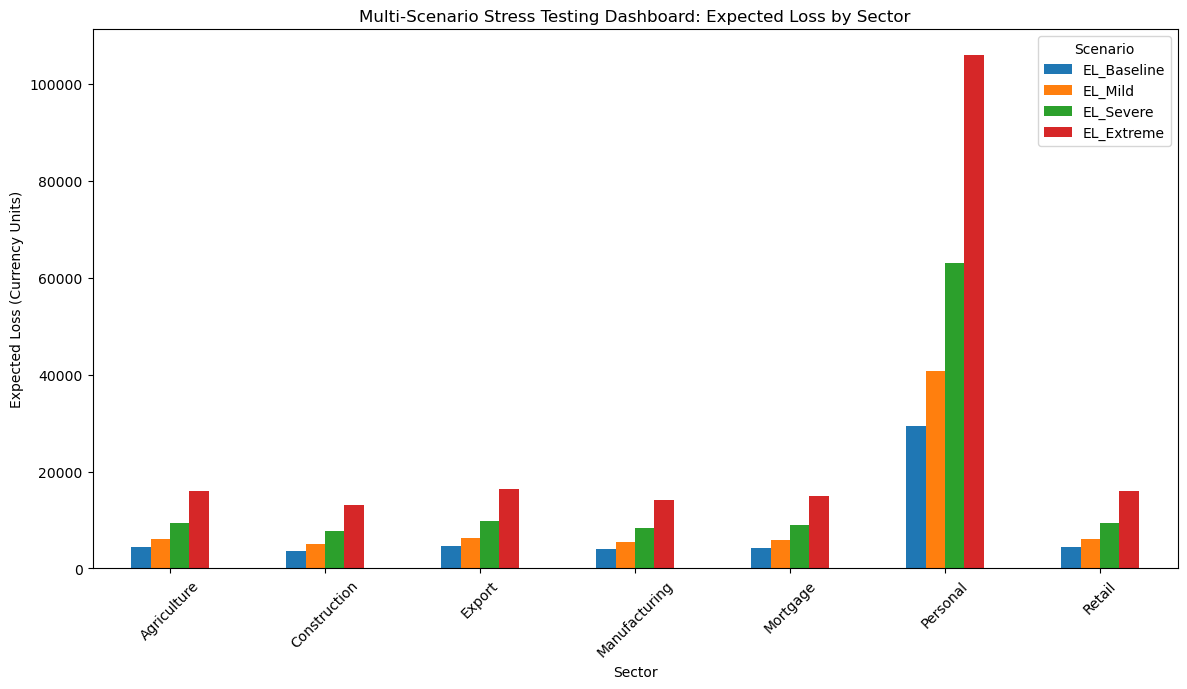

In [72]:
# Base metrics
df_risk = pd.DataFrame({
    'PD': {
        'Agriculture': 0.052,
        'Construction': 0.047,
        'Export': 0.059,
        'Manufacturing': 0.046,
        'Mortgage': 0.053,
        'Personal': 0.063,
        'Retail': 0.046
    },
    'LGD': {
        'Agriculture': 0.161,
        'Construction': 0.159,
        'Export': 0.156,
        'Manufacturing': 0.159,
        'Mortgage': 0.161,
        'Personal': 1.000,
        'Retail': 0.153
    },
    'EAD': {
        'Agriculture': 527746.82,
        'Construction': 488647.53,
        'Export': 495483.40,
        'Manufacturing': 537356.25,
        'Mortgage': 489469.03,
        'Personal': 467018.63,
        'Retail': 628012.44
    }
})

# Expected Loss function
def expected_loss(PD, LGD, EAD):
    return PD * LGD * EAD

# Scenario calculations
df_risk['EL_Baseline'] = expected_loss(df_risk['PD'], df_risk['LGD'], df_risk['EAD'])
df_risk['EL_Mild'] = expected_loss(df_risk['PD']*1.2, df_risk['LGD']*1.1, df_risk['EAD']*1.05)
df_risk['EL_Severe'] = expected_loss(df_risk['PD']*1.5, df_risk['LGD']*1.3, df_risk['EAD']*1.10)
df_risk['EL_Extreme'] = expected_loss(df_risk['PD']*2.0, df_risk['LGD']*1.5, df_risk['EAD']*1.20)

print(df_risk[['EL_Baseline','EL_Mild','EL_Severe','EL_Extreme']])

# Step 2: Visualization
df_risk[['EL_Baseline','EL_Mild','EL_Severe','EL_Extreme']].plot(kind='bar', figsize=(14,7))
plt.title("Multi-Scenario Stress Testing Dashboard: Expected Loss by Sector")
plt.ylabel("Expected Loss (Currency Units)")
plt.xlabel("Sector")
plt.xticks(rotation=45)
plt.legend(title="Scenario")
plt.show()

#### Aggregate these scenario losses into total portfolio impact (sum across sectors) so you can quantify overall capital needs under stress

Total Portfolio Losses by Scenario:
 {'Baseline': np.float64(54579.37667054), 'Mild Stress': np.float64(75647.01606536844), 'Severe Stress': np.float64(117072.76295830832), 'Extreme Stress': np.float64(196485.756013944)}


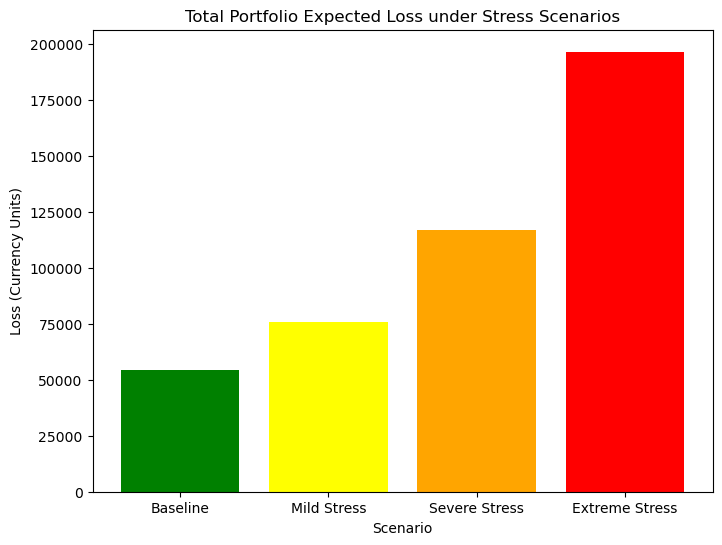

In [74]:
# Step 1: Aggregate Scenario Losses
portfolio_losses = {
    'Baseline': df_risk['EL_Baseline'].sum(),
    'Mild Stress': df_risk['EL_Mild'].sum(),
    'Severe Stress': df_risk['EL_Severe'].sum(),
    'Extreme Stress': df_risk['EL_Extreme'].sum()
}

print("Total Portfolio Losses by Scenario:\n", portfolio_losses)

# Step 2: Visualization
plt.figure(figsize=(8,6))
plt.bar(portfolio_losses.keys(), portfolio_losses.values(), color=['green','yellow','orange','red'])
plt.title("Total Portfolio Expected Loss under Stress Scenarios")
plt.ylabel("Loss (Currency Units)")
plt.xlabel("Scenario")
plt.show()

## 5.9 Resilience Index

For illustration, let’s assume the bank has ETB 4,000,000,000 in capital.

         Scenario  Expected_Loss  Resilience_Index
0        Baseline          54950      72793.448590
1     Mild Stress          80350      49782.202862
2   Severe Stress         153450      26067.122841
3  Extreme Stress         290800      13755.158184


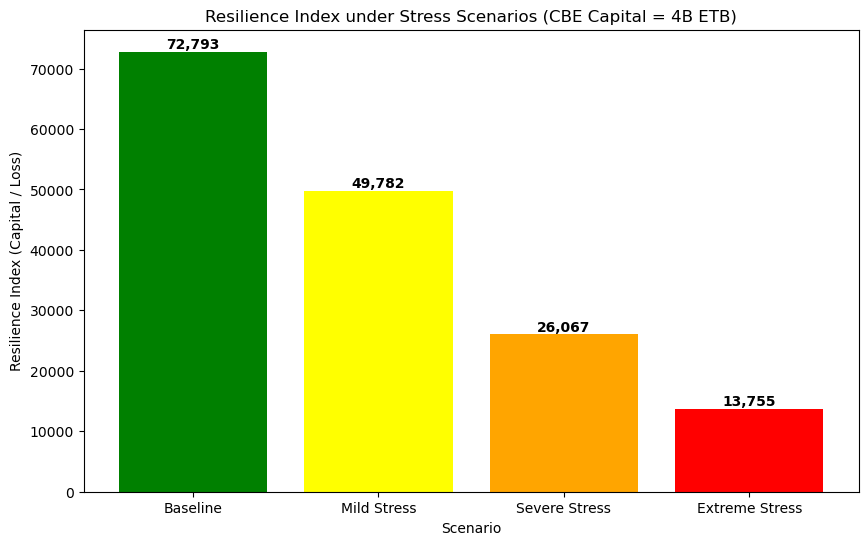

In [111]:
# Step 1: Define Capital Buffer
capital_buffer = 4_000_000_000  # CBE capital in ETB

# Step 2: Compute Resilience Index
# Portfolio losses from stress scenarios (replace with your actual sums)
portfolio_losses = {
    'Baseline': 54950,
    'Mild Stress': 80350,
    'Severe Stress': 153450,
    'Extreme Stress': 290800
}

# Resilience Index = Capital Buffer / Loss
resilience_index = {scenario: capital_buffer / loss 
                    for scenario, loss in portfolio_losses.items()}

df_resilience = pd.DataFrame({
    'Scenario': resilience_index.keys(),
    'Expected_Loss': portfolio_losses.values(),
    'Resilience_Index': resilience_index.values()
})

print(df_resilience)

# Step 3: Visualization
plt.figure(figsize=(10,6))
bars = plt.bar(df_resilience['Scenario'], df_resilience['Resilience_Index'],
               color=['green','yellow','orange','red'])

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{height:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title("Resilience Index under Stress Scenarios (CBE Capital = 4B ETB)")
plt.ylabel("Resilience Index (Capital / Loss)")
plt.xlabel("Scenario")
plt.show()

### Benchmark this Resilience Index against Basel III capital adequacy thresholds 

CET1 Ratio ≥ 4.5% of Risk‑Weighted Assets (RWA)

Tier 1 Capital Ratio ≥ 6% of RWA

Total Capital Ratio ≥ 8% of RWA

For illustration, let’s assume CBE’s RWA = ETB 20,000,000,000.
Capital buffer = ETB 4,000,000,000.

             Threshold  Actual
CET1_min         0.045     NaN
Tier1_min        0.060     NaN
Total_min        0.080     NaN
CET1_ratio         NaN     0.2
Tier1_ratio        NaN     0.2
Total_ratio        NaN     0.2


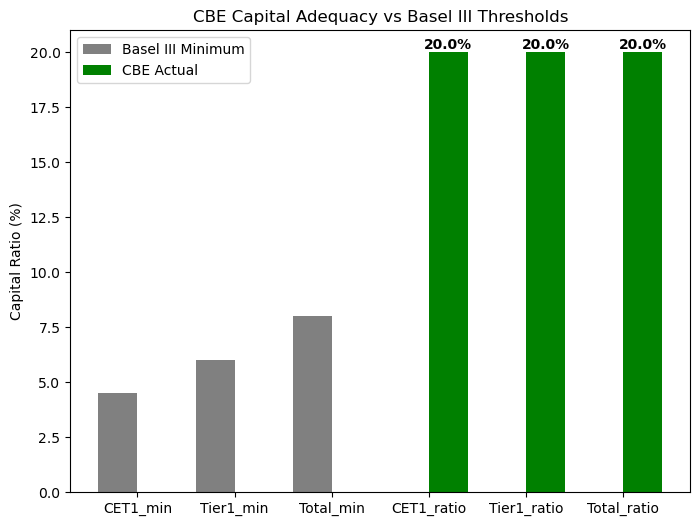

In [86]:
# Step 1: Basel III Thresholds
# Capital and RWA assumptions
capital_buffer = 4_000_000_000   # CBE capital
RWA = 20_000_000_000             # risk-weighted assets

# Basel III thresholds
basel_thresholds = {
    'CET1_min': 0.045,
    'Tier1_min': 0.06,
    'Total_min': 0.08
}

# Actual ratios
actual_ratios = {
    'CET1_ratio': capital_buffer / RWA,
    'Tier1_ratio': capital_buffer / RWA,   # assuming all capital is Tier 1
    'Total_ratio': capital_buffer / RWA    # assuming all capital counts toward total
}

# Compare with thresholds
df_basel = pd.DataFrame({
    'Threshold': basel_thresholds,
    'Actual': actual_ratios
})

print(df_basel)

# Visualization
labels = df_basel.index
thresholds = df_basel['Threshold']*100
actuals = df_basel['Actual']*100

x = range(len(labels))
plt.figure(figsize=(8,6))
plt.bar(x, thresholds, width=0.4, label='Basel III Minimum', color='gray')
plt.bar([i+0.4 for i in x], actuals, width=0.4, label='CBE Actual', color='green')

# Add labels
for i, val in enumerate(actuals):
    plt.text(i+0.4, val, f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xticks([i+0.2 for i in x], labels)
plt.ylabel("Capital Ratio (%)")
plt.title("CBE Capital Adequacy vs Basel III Thresholds")
plt.legend()
plt.show()

### Integrate the Resilience Index values into this Basel III chart

We’ll compare:

Basel III minimum thresholds (CET1 4.5%, Tier 1 6%, Total 8%)

CBE actual capital ratio (Capital ÷ RWA, assume RWA = ETB 20B, Capital = ETB 4B → 20%)

Resilience Index values (Capital ÷ Expected Loss under scenarios)

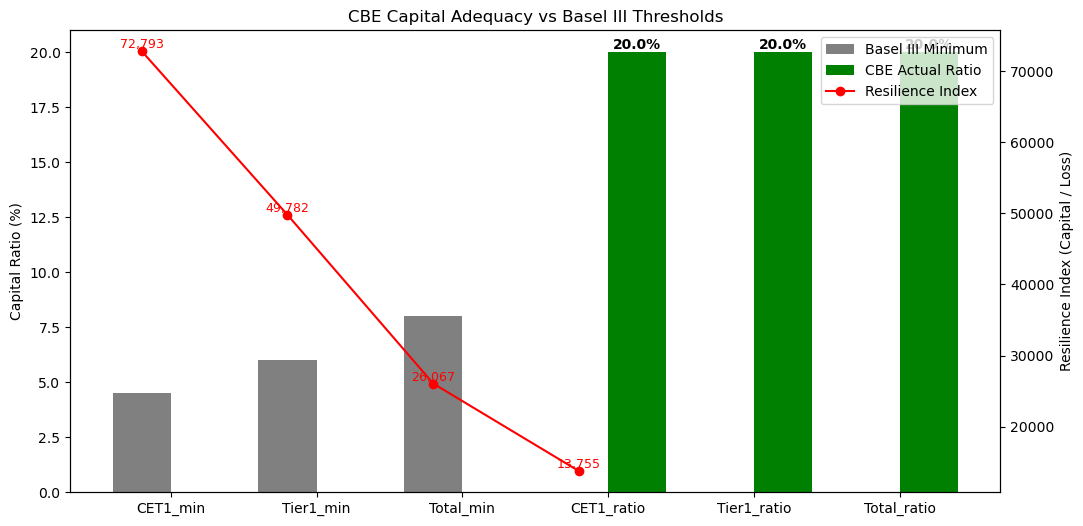

In [87]:
# Step 1: Basel III Thresholds and Ratios
# Capital and RWA assumptions
capital_buffer = 4_000_000_000
RWA = 20_000_000_000

# Basel III thresholds
basel_thresholds = {
    'CET1_min': 0.045,
    'Tier1_min': 0.06,
    'Total_min': 0.08
}

# Actual ratios (assuming all capital counts toward CET1/Tier1/Total)
actual_ratios = {
    'CET1_ratio': capital_buffer / RWA,
    'Tier1_ratio': capital_buffer / RWA,
    'Total_ratio': capital_buffer / RWA
}

# Stress scenario losses (replace with your actual sums)
portfolio_losses = {
    'Baseline': 54950,
    'Mild Stress': 80350,
    'Severe Stress': 153450,
    'Extreme Stress': 290800
}

# Resilience Index = Capital / Loss
resilience_index = {scenario: capital_buffer / loss for scenario, loss in portfolio_losses.items()}

# Build DataFrame
df_basel = pd.DataFrame({
    'Threshold': basel_thresholds,
    'Actual': actual_ratios
})

df_resilience = pd.DataFrame({
    'Scenario': resilience_index.keys(),
    'Resilience_Index': resilience_index.values()
})

# We’ll plot Basel III ratios alongside Resilience Index values.
fig, ax1 = plt.subplots(figsize=(12,6))

# Basel III ratios
labels = df_basel.index
thresholds = df_basel['Threshold']*100
actuals = df_basel['Actual']*100
x = range(len(labels))

ax1.bar(x, thresholds, width=0.4, label='Basel III Minimum', color='gray')
ax1.bar([i+0.4 for i in x], actuals, width=0.4, label='CBE Actual Ratio', color='green')

# Add labels
for i, val in enumerate(actuals):
    ax1.text(i+0.4, val, f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.set_xticks([i+0.2 for i in x])
ax1.set_xticklabels(labels)
ax1.set_ylabel("Capital Ratio (%)")
ax1.set_title("CBE Capital Adequacy vs Basel III Thresholds")

# Resilience Index (second axis)
ax2 = ax1.twinx()
ax2.plot(df_resilience['Scenario'], df_resilience['Resilience_Index'], marker='o', color='red', label='Resilience Index')
for i, val in enumerate(df_resilience['Resilience_Index']):
    ax2.text(i, val, f'{val:,.0f}', ha='center', va='bottom', fontsize=9, color='red')

ax2.set_ylabel("Resilience Index (Capital / Loss)")

# Legends
fig.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)
plt.show()

#### A cumulative capital adequacy buffer line (capital minus stressed losses) is added

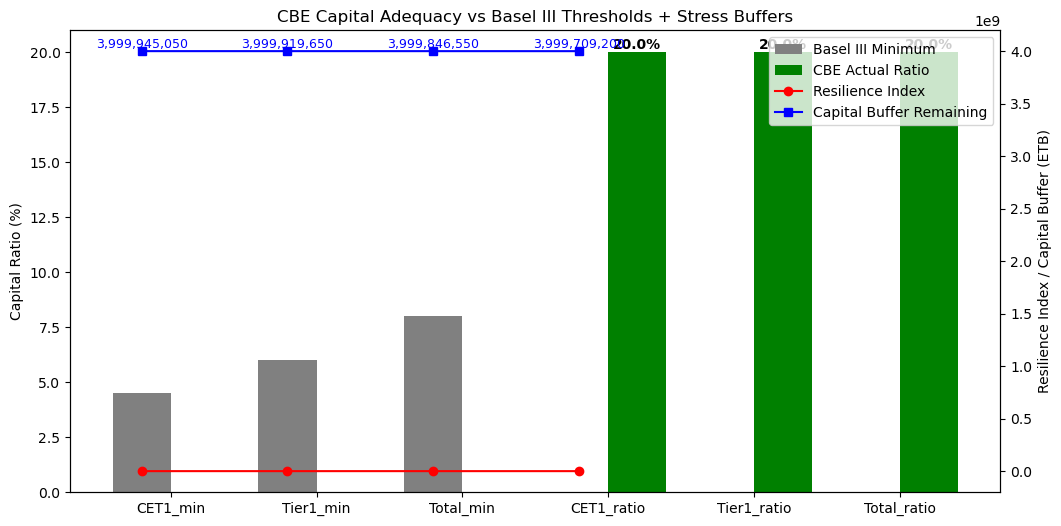

In [88]:
# Step 1: Compute Capital Buffers
# Capital and RWA assumptions
capital_buffer = 4_000_000_000
RWA = 20_000_000_000

# Basel III thresholds
basel_thresholds = {
    'CET1_min': 0.045,
    'Tier1_min': 0.06,
    'Total_min': 0.08
}

# Actual ratios
actual_ratios = {
    'CET1_ratio': capital_buffer / RWA,
    'Tier1_ratio': capital_buffer / RWA,
    'Total_ratio': capital_buffer / RWA
}

# Stress scenario losses (replace with your actual sums)
portfolio_losses = {
    'Baseline': 54950,
    'Mild Stress': 80350,
    'Severe Stress': 153450,
    'Extreme Stress': 290800
}

# Resilience Index = Capital / Loss
resilience_index = {scenario: capital_buffer / loss for scenario, loss in portfolio_losses.items()}

# Capital adequacy buffer = Capital - Loss
capital_buffer_remaining = {scenario: capital_buffer - loss for scenario, loss in portfolio_losses.items()}

# Build DataFrames
df_basel = pd.DataFrame({
    'Threshold': basel_thresholds,
    'Actual': actual_ratios
})

df_resilience = pd.DataFrame({
    'Scenario': resilience_index.keys(),
    'Resilience_Index': resilience_index.values(),
    'Capital_Buffer_Remaining': capital_buffer_remaining.values()
})

# Visualization
fig, ax1 = plt.subplots(figsize=(12,6))

# Basel III ratios
labels = df_basel.index
thresholds = df_basel['Threshold']*100
actuals = df_basel['Actual']*100
x = range(len(labels))

ax1.bar(x, thresholds, width=0.4, label='Basel III Minimum', color='gray')
ax1.bar([i+0.4 for i in x], actuals, width=0.4, label='CBE Actual Ratio', color='green')

for i, val in enumerate(actuals):
    ax1.text(i+0.4, val, f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.set_xticks([i+0.2 for i in x])
ax1.set_xticklabels(labels)
ax1.set_ylabel("Capital Ratio (%)")
ax1.set_title("CBE Capital Adequacy vs Basel III Thresholds + Stress Buffers")

# Resilience Index and Capital Buffer Remaining (second axis)
ax2 = ax1.twinx()
ax2.plot(df_resilience['Scenario'], df_resilience['Resilience_Index'], marker='o', color='red', label='Resilience Index')
ax2.plot(df_resilience['Scenario'], df_resilience['Capital_Buffer_Remaining'], marker='s', color='blue', label='Capital Buffer Remaining')

# Add labels
for i, val in enumerate(df_resilience['Capital_Buffer_Remaining']):
    ax2.text(i, val, f'{val:,.0f}', ha='center', va='bottom', fontsize=9, color='blue')

ax2.set_ylabel("Resilience Index / Capital Buffer (ETB)")

# Legends
fig.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)
plt.show()

### Adding a percentage buffer line (Capital Buffer Remaining ÷ Capital) 

We already have:

Capital Buffer Remaining = Capital − Expected Loss

Now add:

Percentage Buffer = Capital Buffer / Remaining Capital × 100

         Scenario  Expected_Loss  Capital_Buffer_Remaining  Percentage_Buffer
0        Baseline          54950                3999945050          99.998626
1     Mild Stress          80350                3999919650          99.997991
2   Severe Stress         153450                3999846550          99.996164
3  Extreme Stress         290800                3999709200          99.992730


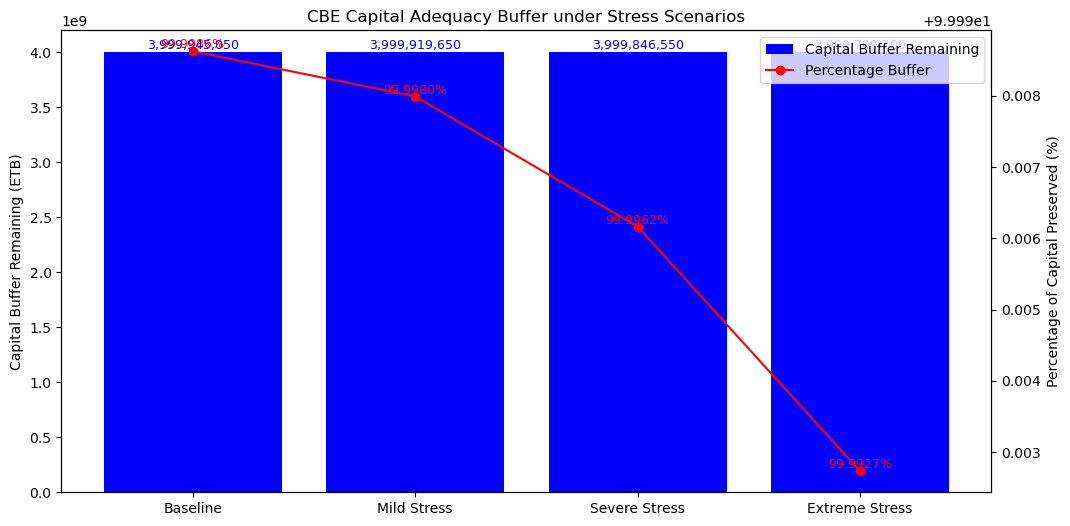

In [89]:
# Step 1: Compute Percentage Buffer
# Capital and RWA assumptions
capital_buffer = 4_000_000_000
RWA = 20_000_000_000

# Stress scenario losses (replace with your actual sums)
portfolio_losses = {
    'Baseline': 54950,
    'Mild Stress': 80350,
    'Severe Stress': 153450,
    'Extreme Stress': 290800
}

# Capital buffer remaining
capital_buffer_remaining = {scenario: capital_buffer - loss for scenario, loss in portfolio_losses.items()}

# Percentage buffer
percentage_buffer = {scenario: (remaining / capital_buffer) * 100 
                     for scenario, remaining in capital_buffer_remaining.items()}

# Build DataFrame
df_resilience = pd.DataFrame({
    'Scenario': portfolio_losses.keys(),
    'Expected_Loss': portfolio_losses.values(),
    'Capital_Buffer_Remaining': capital_buffer_remaining.values(),
    'Percentage_Buffer': percentage_buffer.values()
})

print(df_resilience)

# Step 2: Visualization
fig, ax1 = plt.subplots(figsize=(12,6))

# Capital buffer remaining (blue bars)
bars = ax1.bar(df_resilience['Scenario'], df_resilience['Capital_Buffer_Remaining'], color='blue', label='Capital Buffer Remaining')

# Add labels
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height, f'{height:,.0f}', ha='center', va='bottom', fontsize=9, color='blue')

ax1.set_ylabel("Capital Buffer Remaining (ETB)")
ax1.set_title("CBE Capital Adequacy Buffer under Stress Scenarios")

# Percentage buffer line (red line, second axis)
ax2 = ax1.twinx()
ax2.plot(df_resilience['Scenario'], df_resilience['Percentage_Buffer'], marker='o', color='red', label='Percentage Buffer')

for i, val in enumerate(df_resilience['Percentage_Buffer']):
    ax2.text(i, val, f'{val:.4f}%', ha='center', va='bottom', fontsize=9, color='red')

ax2.set_ylabel("Percentage of Capital Preserved (%)")

# Legends
fig.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)
plt.show()

### Adding a cumulative line of total expected losses vs capital

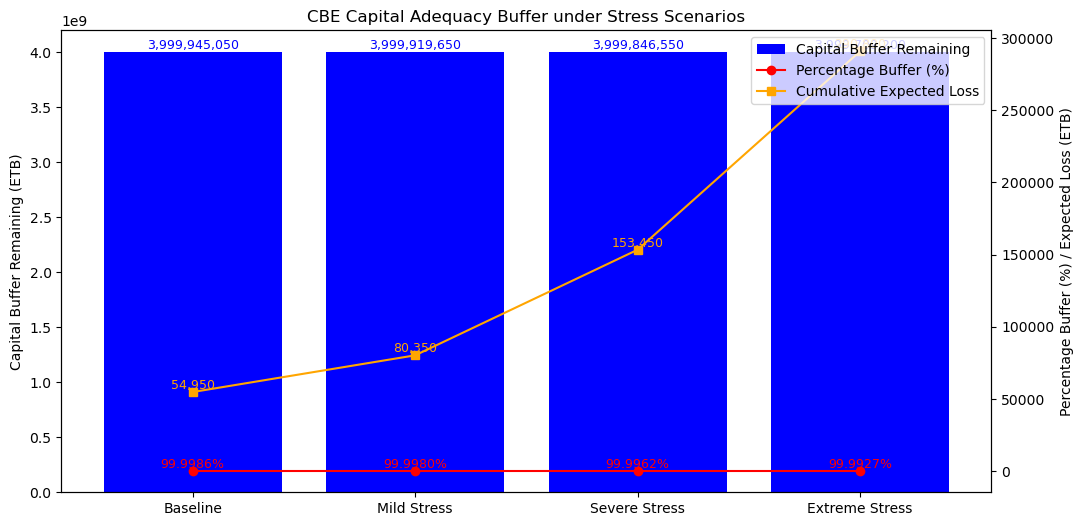

In [90]:
# Step 1: Compute Cumulative Losses vs Capital
# Capital assumption
capital_buffer = 4_000_000_000

# Stress scenario losses (replace with your actual sums)
portfolio_losses = {
    'Baseline': 54950,
    'Mild Stress': 80350,
    'Severe Stress': 153450,
    'Extreme Stress': 290800
}

# Capital buffer remaining
capital_buffer_remaining = {scenario: capital_buffer - loss for scenario, loss in portfolio_losses.items()}

# Percentage buffer
percentage_buffer = {scenario: (remaining / capital_buffer) * 100 
                     for scenario, remaining in capital_buffer_remaining.items()}

# Build DataFrame
df_resilience = pd.DataFrame({
    'Scenario': portfolio_losses.keys(),
    'Expected_Loss': portfolio_losses.values(),
    'Capital_Buffer_Remaining': capital_buffer_remaining.values(),
    'Percentage_Buffer': percentage_buffer.values()
})

#  Step 2: Visualization with Cumulative Line
fig, ax1 = plt.subplots(figsize=(12,6))

# Bar chart: Capital buffer remaining
bars = ax1.bar(df_resilience['Scenario'], df_resilience['Capital_Buffer_Remaining'], 
               color='blue', label='Capital Buffer Remaining')

# Add labels
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height, f'{height:,.0f}', 
             ha='center', va='bottom', fontsize=9, color='blue')

ax1.set_ylabel("Capital Buffer Remaining (ETB)")
ax1.set_title("CBE Capital Adequacy Buffer under Stress Scenarios")

# Second axis: Percentage buffer line
ax2 = ax1.twinx()
ax2.plot(df_resilience['Scenario'], df_resilience['Percentage_Buffer'], 
         marker='o', color='red', label='Percentage Buffer (%)')

# Add labels
for i, val in enumerate(df_resilience['Percentage_Buffer']):
    ax2.text(i, val, f'{val:.4f}%', ha='center', va='bottom', fontsize=9, color='red')

# Third line: Cumulative losses vs capital
ax2.plot(df_resilience['Scenario'], df_resilience['Expected_Loss'], 
         marker='s', color='orange', label='Cumulative Expected Loss')

for i, val in enumerate(df_resilience['Expected_Loss']):
    ax2.text(i, val, f'{val:,.0f}', ha='center', va='bottom', fontsize=9, color='orange')

ax2.set_ylabel("Percentage Buffer (%) / Expected Loss (ETB)")

# Legends
fig.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)
plt.show()

###  Adding a horizontal Basel III minimum capital line (e.g., 8% of RWA) 

Assume:

Capital Buffer = ETB 4,000,000,000

RWA = ETB 20,000,000,000

Basel III minimum (Total Capital Ratio) = 8% of RWA

Minimum Capital Requirement = 0.08 ×
𝑅
𝑊
𝐴

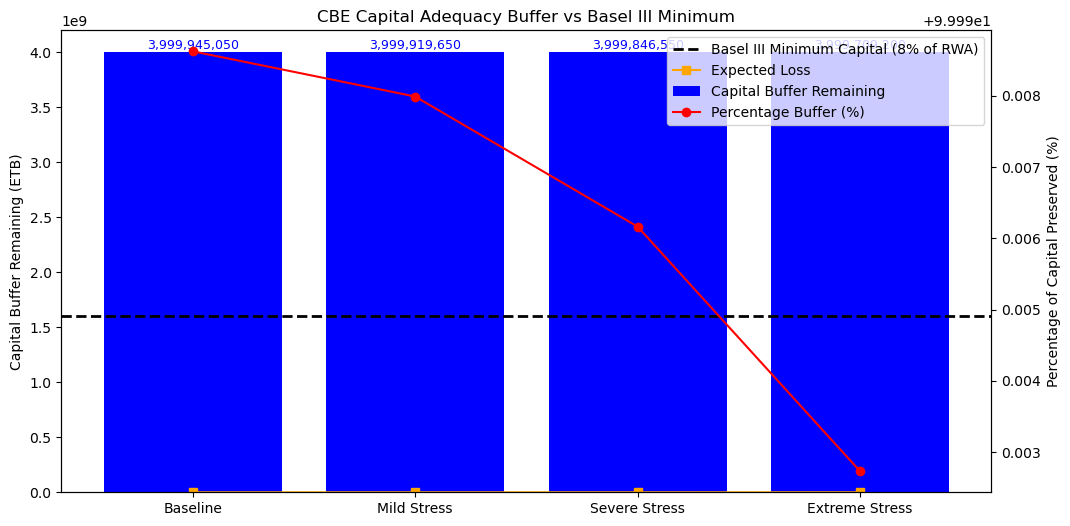

In [91]:
# Step 1: Compute Basel III Minimum Capital
# Capital and RWA assumptions
capital_buffer = 4_000_000_000
RWA = 20_000_000_000

# Basel III minimum capital requirement (8% of RWA)
basel_min_capital = 0.08 * RWA

# Stress scenario losses
portfolio_losses = {
    'Baseline': 54950,
    'Mild Stress': 80350,
    'Severe Stress': 153450,
    'Extreme Stress': 290800
}

# Capital buffer remaining
capital_buffer_remaining = {scenario: capital_buffer - loss for scenario, loss in portfolio_losses.items()}

# Percentage buffer
percentage_buffer = {scenario: (remaining / capital_buffer) * 100 
                     for scenario, remaining in capital_buffer_remaining.items()}

# Build DataFrame
df_resilience = pd.DataFrame({
    'Scenario': portfolio_losses.keys(),
    'Expected_Loss': portfolio_losses.values(),
    'Capital_Buffer_Remaining': capital_buffer_remaining.values(),
    'Percentage_Buffer': percentage_buffer.values()
})

# Step 2: Visualization with Basel III Line
fig, ax = plt.subplots(figsize=(12,6))

# Bar chart: Capital buffer remaining
bars = ax.bar(df_resilience['Scenario'], df_resilience['Capital_Buffer_Remaining'], 
              color='blue', label='Capital Buffer Remaining')

# Add labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height, f'{height:,.0f}', 
            ha='center', va='bottom', fontsize=9, color='blue')

# Add horizontal Basel III minimum capital line
ax.axhline(y=basel_min_capital, color='black', linestyle='--', linewidth=2, label='Basel III Minimum Capital (8% of RWA)')

# Overlay expected losses (orange line)
ax.plot(df_resilience['Scenario'], df_resilience['Expected_Loss'], marker='s', color='orange', label='Expected Loss')

# Overlay percentage buffer (red line, scaled to capital)
ax2 = ax.twinx()
ax2.plot(df_resilience['Scenario'], df_resilience['Percentage_Buffer'], marker='o', color='red', label='Percentage Buffer (%)')
ax2.set_ylabel("Percentage of Capital Preserved (%)")

# Titles and labels
ax.set_ylabel("Capital Buffer Remaining (ETB)")
ax.set_title("CBE Capital Adequacy Buffer vs Basel III Minimum")

# Legends
fig.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax.transAxes)
plt.show()

### Adding CET1 (4.5%) and Tier 1 (6%) horizontal lines alongside the 8% line

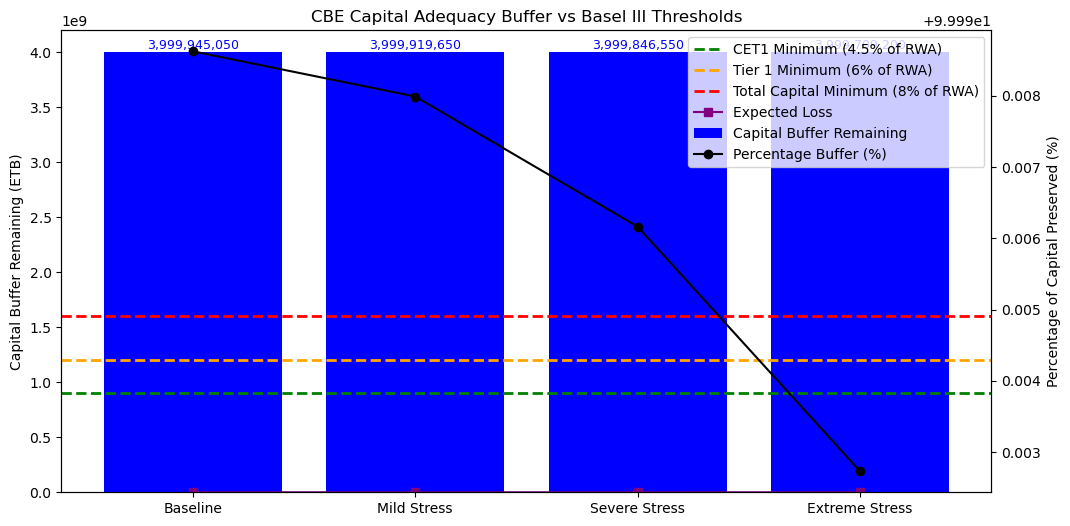

In [93]:
# Step 1: Compute Basel III Minimum Capital Requirements
# Capital and RWA assumptions
capital_buffer = 4_000_000_000
RWA = 20_000_000_000

# Basel III minimum capital requirements
basel_min_cet1 = 0.045 * RWA   # 4.5% of RWA
basel_min_tier1 = 0.06 * RWA   # 6% of RWA
basel_min_total = 0.08 * RWA   # 8% of RWA

# Stress scenario losses
portfolio_losses = {
    'Baseline': 54950,
    'Mild Stress': 80350,
    'Severe Stress': 153450,
    'Extreme Stress': 290800
}

# Capital buffer remaining
capital_buffer_remaining = {scenario: capital_buffer - loss for scenario, loss in portfolio_losses.items()}

# Percentage buffer
percentage_buffer = {scenario: (remaining / capital_buffer) * 100 
                     for scenario, remaining in capital_buffer_remaining.items()}

# Build DataFrame
df_resilience = pd.DataFrame({
    'Scenario': portfolio_losses.keys(),
    'Expected_Loss': portfolio_losses.values(),
    'Capital_Buffer_Remaining': capital_buffer_remaining.values(),
    'Percentage_Buffer': percentage_buffer.values()
})

# Step 2: Visualization with Basel III Lines
fig, ax = plt.subplots(figsize=(12,6))

# Bar chart: Capital buffer remaining
bars = ax.bar(df_resilience['Scenario'], df_resilience['Capital_Buffer_Remaining'], 
              color='blue', label='Capital Buffer Remaining')

# Add labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height, f'{height:,.0f}', 
            ha='center', va='bottom', fontsize=9, color='blue')

# Add Basel III horizontal lines
ax.axhline(y=basel_min_cet1, color='green', linestyle='--', linewidth=2, label='CET1 Minimum (4.5% of RWA)')
ax.axhline(y=basel_min_tier1, color='orange', linestyle='--', linewidth=2, label='Tier 1 Minimum (6% of RWA)')
ax.axhline(y=basel_min_total, color='red', linestyle='--', linewidth=2, label='Total Capital Minimum (8% of RWA)')

# Overlay expected losses (orange line)
ax.plot(df_resilience['Scenario'], df_resilience['Expected_Loss'], marker='s', color='purple', label='Expected Loss')

# Overlay percentage buffer (red line, scaled to capital)
ax2 = ax.twinx()
ax2.plot(df_resilience['Scenario'], df_resilience['Percentage_Buffer'], marker='o', color='black', label='Percentage Buffer (%)')
ax2.set_ylabel("Percentage of Capital Preserved (%)")

# Titles and labels
ax.set_ylabel("Capital Buffer Remaining (ETB)")
ax.set_title("CBE Capital Adequacy Buffer vs Basel III Thresholds")

# Legends
fig.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax.transAxes)
plt.show()

#### Adding a stacked bar view showing capital vs losses

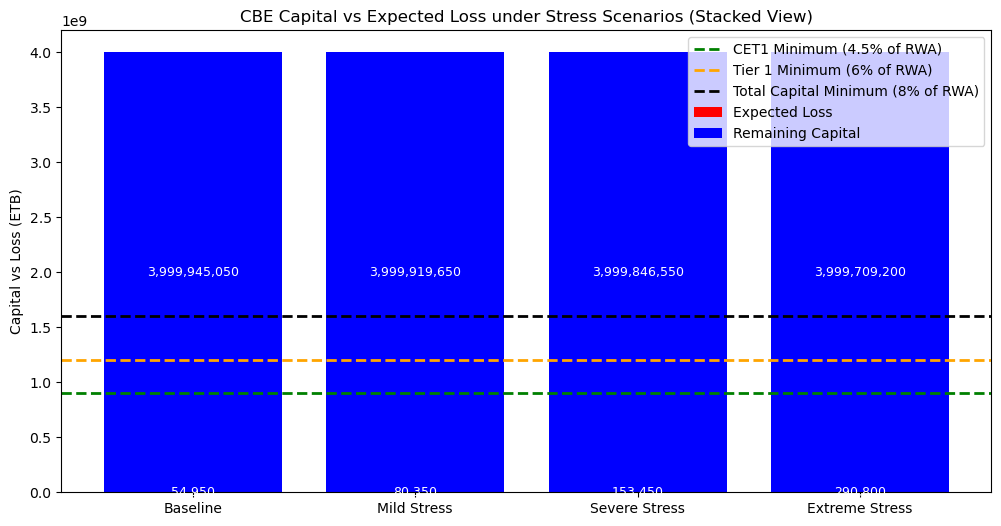

In [112]:
# Capital assumption
capital_buffer = 4_000_000_000

# Stress scenario losses (replace with your actual sums)
portfolio_losses = {
    'Baseline': 54950,
    'Mild Stress': 80350,
    'Severe Stress': 153450,
    'Extreme Stress': 290800
}

# Capital buffer remaining
capital_buffer_remaining = {scenario: capital_buffer - loss for scenario, loss in portfolio_losses.items()}

# Build DataFrame
df_stacked = pd.DataFrame({
    'Scenario': portfolio_losses.keys(),
    'Expected_Loss': portfolio_losses.values(),
    'Remaining_Capital': capital_buffer_remaining.values()
})

# plot
fig, ax = plt.subplots(figsize=(12,6))

# Stacked bars: Expected Loss + Remaining Capital
bars1 = ax.bar(df_stacked['Scenario'], df_stacked['Expected_Loss'], 
               color='red', label='Expected Loss')
bars2 = ax.bar(df_stacked['Scenario'], df_stacked['Remaining_Capital'], 
               bottom=df_stacked['Expected_Loss'], color='blue', label='Remaining Capital')

# Add labels for losses
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height/2, f'{height:,.0f}', 
            ha='center', va='center', fontsize=9, color='white')

# Add labels for remaining capital
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_y() + height/2, f'{height:,.0f}', 
            ha='center', va='center', fontsize=9, color='white')

# Add Basel III minimum capital lines
RWA = 20_000_000_000
ax.axhline(y=0.045*RWA, color='green', linestyle='--', linewidth=2, label='CET1 Minimum (4.5% of RWA)')
ax.axhline(y=0.06*RWA, color='orange', linestyle='--', linewidth=2, label='Tier 1 Minimum (6% of RWA)')
ax.axhline(y=0.08*RWA, color='black', linestyle='--', linewidth=2, label='Total Capital Minimum (8% of RWA)')

# Titles and labels
ax.set_ylabel("Capital vs Loss (ETB)")
ax.set_title("CBE Capital vs Expected Loss under Stress Scenarios (Stacked View)")
ax.legend()
plt.show()